In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [3]:
# Load main dataset
df = pd.read_csv("cleaned_stock_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'Company'])

# Pivot prices and returns
prices = df.pivot(index='Date', columns='Company', values='Close')
returns = df.pivot(index='Date', columns='Company', values='Return')

print("prices:", prices.shape)
print("returns:", returns.shape)

prices: (10270, 102)
returns: (10270, 102)


In [7]:
mispricing_df = pd.read_csv("mispricing_residuals.csv", index_col='date')
mispricing_df.index = pd.to_datetime(mispricing_df.index)

topo_df = pd.read_csv("topology_features.csv", index_col='date')
topo_df.index = pd.to_datetime(topo_df.index)

print("mispricing:", mispricing_df.shape)
print("topology:", topo_df.shape)

mispricing: (2042, 102)
topology: (2042, 6)


In [9]:
H = 5  # horizon in days

# 5-day forward stock returns
stock_fwd = prices.pct_change(periods=H).shift(-H)

# Simple index proxy: equal-weight across all companies
index_price = prices.mean(axis=1)
index_fwd = index_price.pct_change(periods=H).shift(-H)

print("stock_fwd:", stock_fwd.shape)

stock_fwd: (10270, 102)


/var/folders/hl/vccl5tsj2_1gxks1lv3sm2hr0000gn/T/ipykernel_2684/2561739149.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_fwd = prices.pct_change(periods=H).shift(-H)


In [11]:
# Align index_fwd as DataFrame with same columns as stocks for broadcasting
index_fwd_df = pd.DataFrame(
    np.repeat(index_fwd.values[:, None], stock_fwd.shape[1], axis=1),
    index=stock_fwd.index,
    columns=stock_fwd.columns
)

y = (stock_fwd > index_fwd_df).astype(int)

print("labels y:", y.shape)
y.head()

labels y: (10270, 102)


Company,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AMAT,AMD,AMGN,...,TSLA,TTD,TTWO,TXN,VRSK,VRTX,WBD,WDAY,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
1985-02-01,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1985-02-04,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1985-02-05,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1985-02-06,0,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1985-02-07,0,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [13]:
common_dates = (
    returns.index
    .intersection(mispricing_df.index)
    .intersection(topo_df.index)
    .intersection(y.index)
    .intersection(stock_fwd.index)
)

common_dates = common_dates.sort_values()
len(common_dates)

2042

In [15]:
# 20-day volatility from daily returns
vol_20 = returns.rolling(20).std()

In [17]:
feature_rows = []
target_rows = []

for date in common_dates:
    # Signals on that date
    eps_today = mispricing_df.loc[date]    # Series: index = Company
    topo_today = topo_df.loc[date]         # Series: H0_*, H1_*
    vol_today = vol_20.loc[date]           # Series: index = Company
    y_today   = y.loc[date]                # Series: index = Company

    # Align on the intersection of companies that are not NaN
    companies = (
        eps_today.index
        .intersection(vol_today.index)
        .intersection(y_today.index)
        .intersection(stock_fwd.columns)
    )

    X_date = pd.DataFrame({
        'epsilon': eps_today[companies],
        'vol_20': vol_today[companies],
    })

    # Drop rows where any feature is NaN
    X_date = X_date.dropna()

    if X_date.empty:
        continue

    # Target restricted to companies we kept
    y_date = y_today[X_date.index]

    # Add topology features as columns (broadcast same value for all companies that date)
    for col in topo_today.index:
        X_date[col] = topo_today[col]

    # Keep date and company as columns (for later grouping & backtest)
    X_date['Date'] = date
    X_date['Company'] = X_date.index

    feature_rows.append(X_date)
    target_rows.append(y_date.reindex(X_date.index))
    

X_all = pd.concat(feature_rows)
y_all = pd.concat(target_rows)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
X_all.head()

X_all shape: (135581, 10)
y_all shape: (135581,)


,epsilon,vol_20,H0_count_long,H0_sum_pers,H0_max_pers,H1_count_long,H1_sum_pers,H1_max_pers,Date,Company
AAPL,0.000000,0.030084,101.0,137.339838,1.414214,4.0,0.220785,0.052675,1985-04-29,AAPL
ADI,-0.004902,0.041546,101.0,137.339838,1.414214,4.0,0.220785,0.052675,1985-04-29,ADI
ADP,-0.001646,0.010738,101.0,137.339838,1.414214,4.0,0.220785,0.052675,1985-04-29,ADP
AEP,0.000000,0.005146,101.0,137.339838,1.414214,4.0,0.220785,0.052675,1985-04-29,AEP
AMAT,-0.003722,0.020481,101.0,137.339838,1.414214,4.0,0.220785,0.052675,1985-04-29,AMAT


In [19]:
feature_cols = [c for c in X_all.columns if c not in ['Date', 'Company']]
X_features = X_all[feature_cols]

X_features.head()

,epsilon,vol_20,H0_count_long,H0_sum_pers,H0_max_pers,H1_count_long,H1_sum_pers,H1_max_pers
AAPL,0.000000,0.030084,101.0,137.339838,1.414214,4.0,0.220785,0.052675
ADI,-0.004902,0.041546,101.0,137.339838,1.414214,4.0,0.220785,0.052675
ADP,-0.001646,0.010738,101.0,137.339838,1.414214,4.0,0.220785,0.052675
AEP,0.000000,0.005146,101.0,137.339838,1.414214,4.0,0.220785,0.052675
AMAT,-0.003722,0.020481,101.0,137.339838,1.414214,4.0,0.220785,0.052675


In [21]:
SPLIT_DATE = pd.Timestamp("2020-01-01")

train_mask = X_all['Date'] < SPLIT_DATE
test_mask  = X_all['Date'] >= SPLIT_DATE

X_train = X_features[train_mask]
X_test  = X_features[test_mask]

y_train = y_all[train_mask]
y_test  = y_all[test_mask]

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 106745 Test size: 28836


In [23]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)

clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [25]:
from sklearn.metrics import roc_auc_score

y_pred_proba_test = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba_test)
print("Test AUC:", auc)

Test AUC: 0.49222696273044075


In [27]:
X_test_full = X_all[test_mask].copy()
X_test_full_features = X_test_full[feature_cols]

X_test_full['proba'] = clf.predict_proba(X_test_full_features)[:, 1]
X_test_full.head()

,epsilon,vol_20,H0_count_long,H0_sum_pers,H0_max_pers,H1_count_long,H1_sum_pers,H1_max_pers,Date,Company,proba
AAPL,0.009938,0.008852,101.0,98.92581,1.414214,42.0,2.243475,0.1207,2020-01-08,AAPL,0.490162
ADBE,-0.017752,0.010928,101.0,98.92581,1.414214,42.0,2.243475,0.1207,2020-01-08,ADBE,0.528958
ADI,-0.000637,0.010806,101.0,98.92581,1.414214,42.0,2.243475,0.1207,2020-01-08,ADI,0.494738
ADP,-0.025595,0.006363,101.0,98.92581,1.414214,42.0,2.243475,0.1207,2020-01-08,ADP,0.540389
ADSK,-0.005919,0.011530,101.0,98.92581,1.414214,42.0,2.243475,0.1207,2020-01-08,ADSK,0.522399


In [29]:
N = 20  # number of stocks to long each date
H = 5   # forward horizon (must match above)

portfolio_returns = []

test_dates = sorted(X_test_full['Date'].unique())

for date in test_dates:
    rows = X_test_full[X_test_full['Date'] == date]
    if rows.empty:
        continue
    
    top = rows.nlargest(N, 'proba')
    tickers = top['Company'].values
    
    # use stock_fwd for realized returns
    if date not in stock_fwd.index:
        continue
    
    r_fwd = stock_fwd.loc[date, tickers].mean(skipna=True)
    
    portfolio_returns.append((date, r_fwd))

port_df = pd.DataFrame(portfolio_returns, columns=['Date', 'ret']).set_index('Date')
port_df.head()

,ret
Date,
2020-01-08,0.018589
2020-01-15,0.029616
2020-01-23,-0.015166
2020-01-30,0.025890
2020-02-06,0.026084


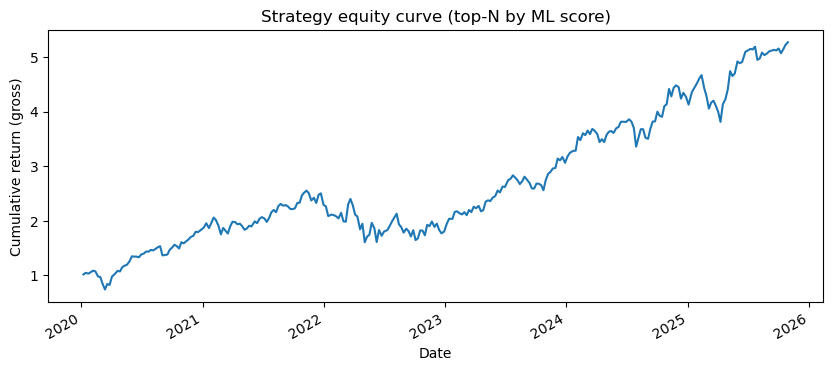

Approx. Sharpe: 2.37703648645263


In [31]:
# Equity curve
equity = (1 + port_df['ret']).cumprod()

plt.figure(figsize=(10, 4))
equity.plot()
plt.title("Strategy equity curve (top-N by ML score)")
plt.xlabel("Date")
plt.ylabel("Cumulative return (gross)")
plt.show()

# Annualized Sharpe (approx, assuming 252 trading days, horizon H)
daily_like_ret = port_df['ret'] / H  # rough conversion
sharpe = daily_like_ret.mean() / daily_like_ret.std() * np.sqrt(252)
print("Approx. Sharpe:", sharpe)

In [33]:
base_feature_cols = ['epsilon', 'vol_20']  # no topology

X_train_base = X_all.loc[train_mask, base_feature_cols]
X_test_base  = X_all.loc[test_mask, base_feature_cols]

clf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)
clf_base.fit(X_train_base, y_train)

y_pred_proba_test_base = clf_base.predict_proba(X_test_base)[:, 1]
auc_base = roc_auc_score(y_test, y_pred_proba_test_base)
print("Baseline (epsilon+vol) AUC:", auc_base)
print("Full (epsilon+vol+topology) AUC:", auc)

Baseline (epsilon+vol) AUC: 0.5088464988900059
Full (epsilon+vol+topology) AUC: 0.49222696273044075


In [35]:
H = 5

# forward returns (you already have stock_fwd)
# stock_fwd = prices.pct_change(periods=H).shift(-H)

ics = []
for date in common_dates:
    eps = mispricing_df.loc[date]
    fwd = stock_fwd.loc[date]

    # align
    s = eps.index.intersection(fwd.index)
    eps_d = eps[s]
    fwd_d = fwd[s]

    mask = (~eps_d.isna()) & (~fwd_d.isna())
    if mask.sum() < 10:
        continue

    ic = np.corrcoef(eps_d[mask], fwd_d[mask])[0, 1]
    ics.append(ic)

print("Mean daily IC of epsilon:", np.nanmean(ics))
print("Std of IC:", np.nanstd(ics))

Mean daily IC of epsilon: -0.03221113118681676
Std of IC: 0.17410992048410767


In [37]:
print("Label distribution:", y_all.value_counts(normalize=True))

Label distribution: 1    0.500159
0    0.499841
Name: proportion, dtype: float64
